<a href="https://colab.research.google.com/github/Jeffrey1999/Deep-Learning/blob/main/ATTENTIVESECURE_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===============================
# ATTENTIVESECURE v5: HIGH ACCURACY (Target: ≥94.5%)
# ===============================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-learn tensorflow matplotlib seaborn

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# === CONFIG ===
DATA_PATH = "/content/drive/MyDrive/Datasets/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"
LABEL_COLUMN = 'Attack_type'
SAMPLE_SIZE = 1_500_000  # ↑↑↑ Increased from 500k

# === 1. Load Data ===
print("Loading dataset...")
df = pd.read_csv(DATA_PATH, low_memory=False)

if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    print(f"Stratified sampling to {SAMPLE_SIZE:,} rows...")
    df = df.groupby(LABEL_COLUMN, group_keys=False).apply(
        lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42)
    ).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")

# === 2. Preprocess ===
X = df.drop(columns=[LABEL_COLUMN])
y = df[LABEL_COLUMN]

X = X.select_dtypes(include=[np.number]).astype(np.float32)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

# ✅ Use RobustScaler (better than MinMax for outliers)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# === 3. Focal Loss (Tuned for Edge-IIoTset) ===
def focal_loss(gamma=1.0, alpha=0.75):
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * -tf.math.log(p_t))
    return loss

# === 4. Model: Deeper CNN + Optimized Transformer ===
def se_block(x, ratio=8):
    filters = x.shape[-1]
    se = tf.keras.layers.GlobalAveragePooling1D()(x)
    se = tf.keras.layers.Dense(filters // ratio, activation='relu')(se)
    se = tf.keras.layers.Dense(filters, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape((1, filters))(se)
    return tf.keras.layers.Multiply()([x, se])

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.15):  # ↓ dropout
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([tf.keras.layers.Dense(ff_dim, activation="relu"), tf.keras.layers.Dense(embed_dim)])
        self.ln1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(rate)
        self.drop2 = tf.keras.layers.Dropout(rate)
    def call(self, x, training=None):
        x = self.ln1(x + self.drop1(self.att(x, x), training=training))
        return self.ln2(x + self.drop2(self.ffn(x), training=training))

def build_model(input_dim, num_classes):
    inp = tf.keras.Input(shape=(1, input_dim))
    # ↑↑↑ Deeper CNN (like sSecure Net)
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(inp)
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(x)  # ← Second layer
    x = tf.keras.layers.Dropout(0.15)(x)  # ↓ dropout
    x = se_block(x)
    x = tf.keras.layers.Dense(64)(x)  # match embed_dim
    x = x + tf.Variable(tf.zeros((1, 1, 64)), trainable=False)
    x = TransformerBlock(64, 4, 128)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.15)(x)
    out = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inp, out)



Mounted at /content/drive
Loading dataset...
Stratified sampling to 1,500,000 rows...


/tmp/ipython-input-98392952.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(LABEL_COLUMN, group_keys=False).apply(


Dataset shape: (1499993, 63)


In [ ]:
model = build_model(X_reshaped.shape[2], num_classes)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1, 43)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1, 64)     │      2,816 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1, 64)     │      4,160 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1, 64)     │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        576 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 64)     │          0 │ dropout[0][0],    │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1, 64)     │      4,160 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 64)     │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block   │ (None, 1, 64)     │     83,200 │ add[0][0]         │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 15)        │      1,935 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 105,687 (412.84 KB)

 Trainable params: 105,687 (412.84 KB)

 Non-trainable params: 0 (0.00 B)

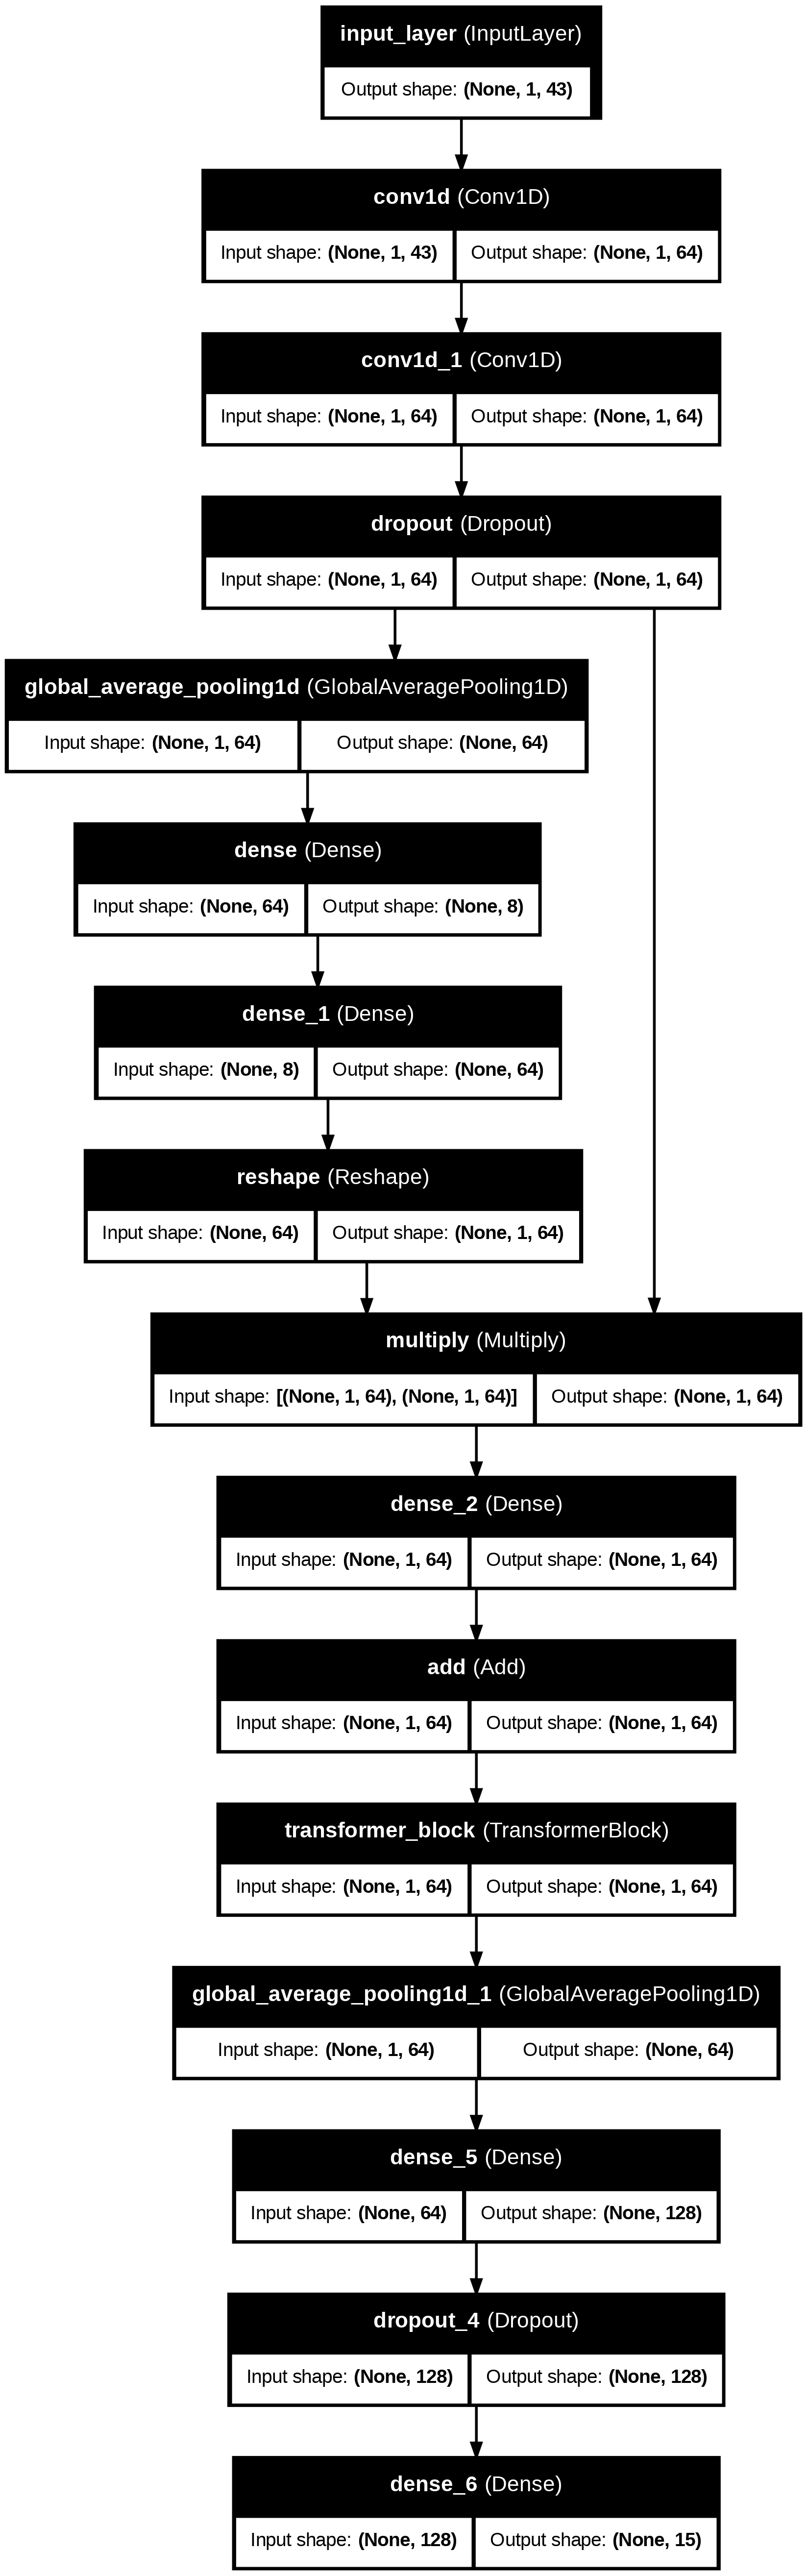

In [ ]:
tf.keras.utils.plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

In [ ]:
print("Model Layer Output Sizes (Sequence Length x Features):")
print(f"  Input Layer: 1x{X_reshaped.shape[2]} (sequence length x features)")
print(f"  After 1st Conv1D layer: 1x64")
print(f"  After 2nd Conv1D layer: 1x64")
print(f"  After SE Block: 1x64")
print(f"  After Dense layer (before Transformer): 1x64")
print(f"  After Transformer Block: 1x64 (embed_dim)")
print(f"  After GlobalAveragePooling1D: 64 (features, sequence length reduced to 1 by pooling)")
print(f"  After 1st Dense layer (before output): 128 (features)")
print(f"  Output Layer: {num_classes} (classes)")

Model Layer Output Sizes (Sequence Length x Features):
  Input Layer: 1x43 (sequence length x features)
  After 1st Conv1D layer: 1x64
  After 2nd Conv1D layer: 1x64
  After SE Block: 1x64
  After Dense layer (before Transformer): 1x64
  After Transformer Block: 1x64 (embed_dim)
  After GlobalAveragePooling1D: 64 (features, sequence length reduced to 1 by pooling)
  After 1st Dense layer (before output): 128 (features)
  Output Layer: 15 (classes)
